In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.model_selection import train_test_split
import cv2
#from google.colab.patches import cv2_imshow
from PIL import Image 
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense,Conv2D , MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow_hub as hub 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns


In [2]:
Normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
Stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"

In [3]:
normal_folder = os.listdir(Normal_path)
stroke_folder = os.listdir(Stroke_path)

In [4]:
print("Images in Normal Data:",len(normal_folder))
print("Images in Stroke Data:",len(stroke_folder))

Images in Normal Data: 1551
Images in Stroke Data: 950


In [5]:
Normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
Stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"

data = []

for img_file in normal_folder:
    image = Image.open("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal\\" + img_file)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    
for img_file in stroke_folder:
    image = Image.open("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\" + img_file)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

In [6]:
len(data)

2501

In [7]:
data[0].shape

(128, 128, 3)

In [8]:
data[0]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [3, 3, 3],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [5, 5, 5],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [1, 1, 1],
        [1, 1, 1]]], dtype=uint8)

In [9]:
normal_label = [0]*len(normal_folder)
stroke_label = [1]*len(stroke_folder)

In [10]:
Target_label = normal_label + stroke_label


In [11]:
len(Target_label)

2501

In [12]:
x = np.array(data)
y = np.array(Target_label)

In [13]:
x[0]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [3, 3, 3],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [5, 5, 5],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [1, 1, 1],
        [1, 1, 1]]], dtype=uint8)

In [14]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.10,shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2250, 128, 128, 3)
(251, 128, 128, 3)
(2250,)
(251,)


In [16]:
x_train_s = (x_train / 255).astype(np.float32)
x_test_s = (x_test / 255).astype(np.float32)


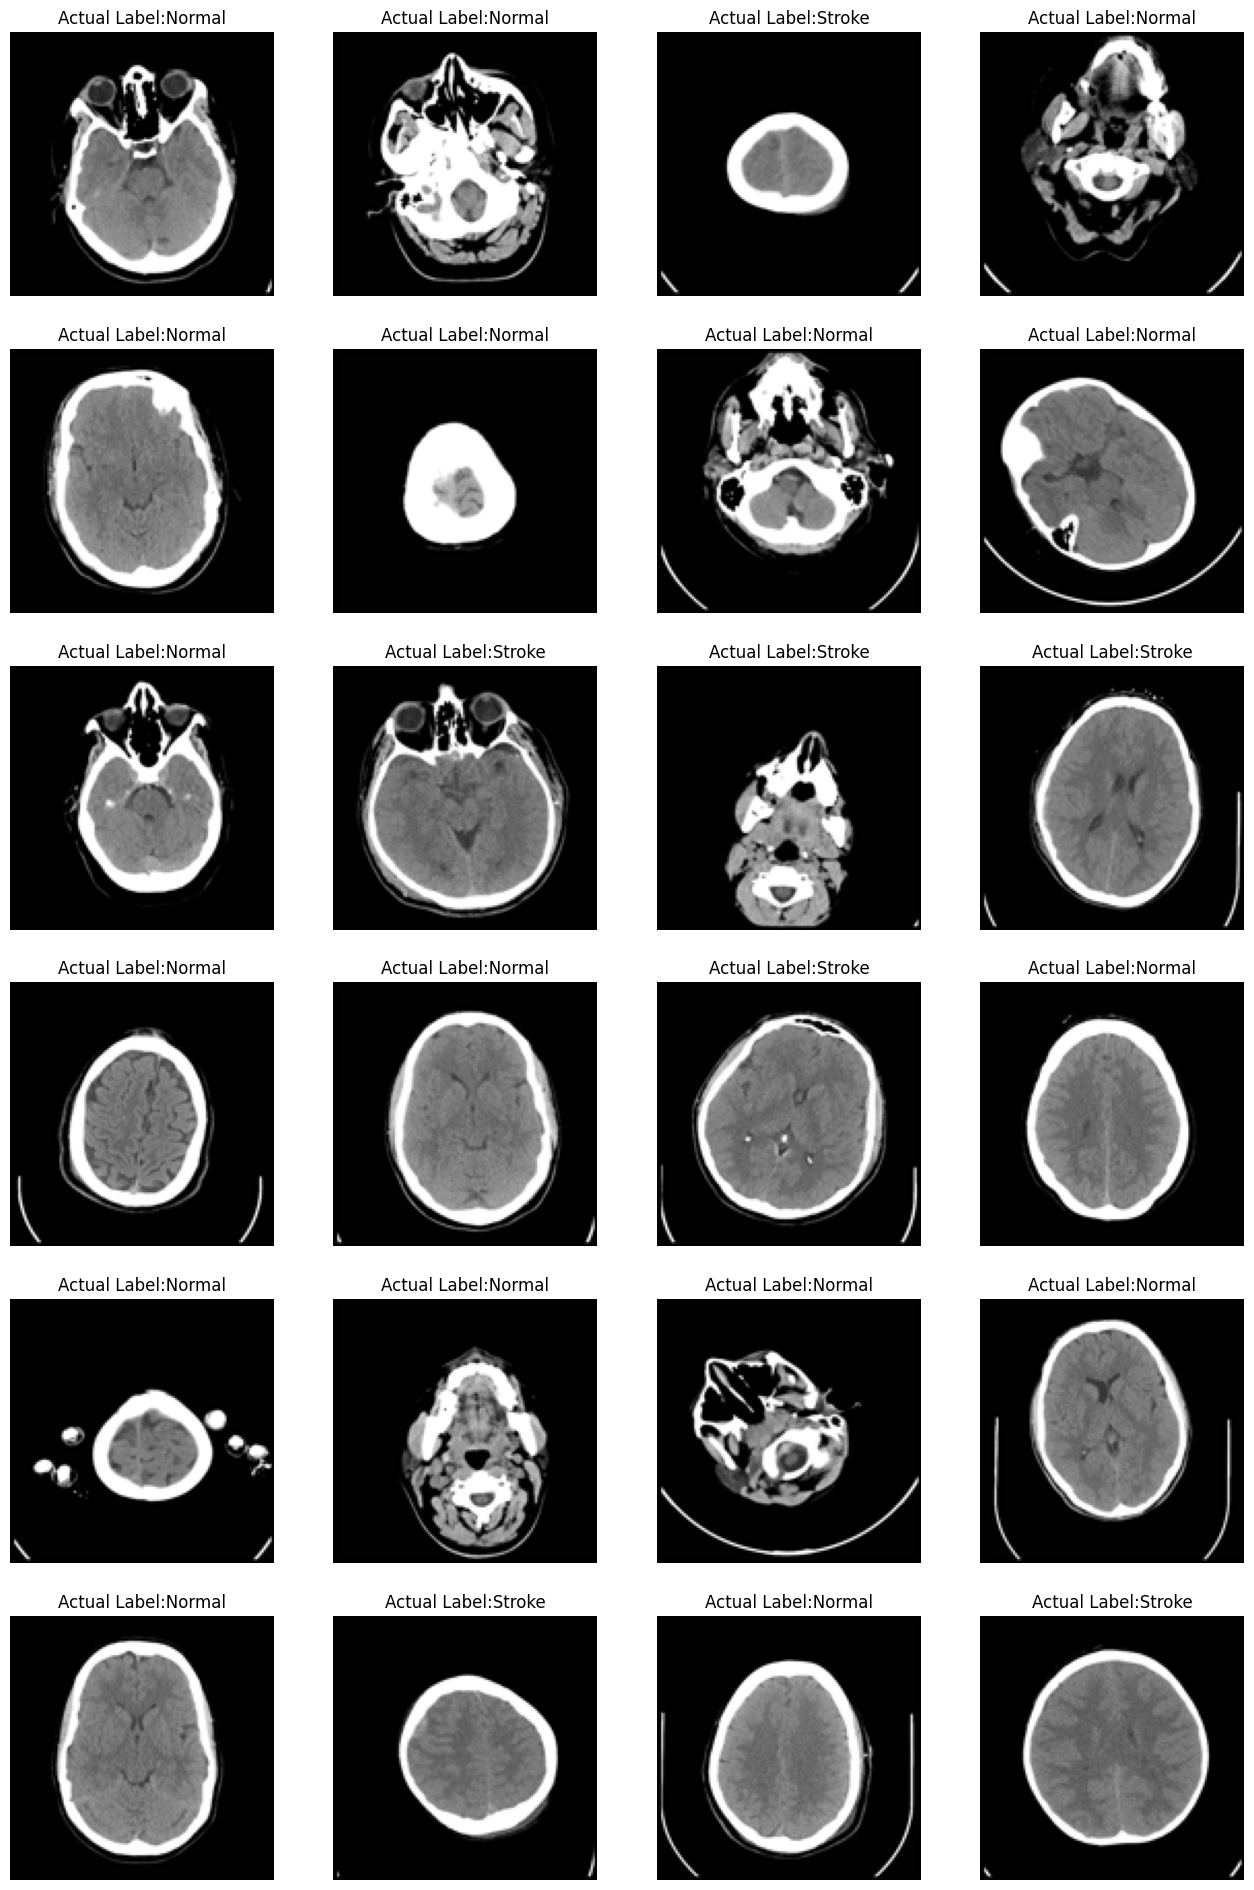

In [17]:
class_labels = ["Normal","Stroke"]
plt.figure(figsize=(16,24))
for i in range(24):
    plt.subplot(6,4,i+1)
    plt.imshow(x_train[i])
    plt.title(f"Actual Label:{class_labels[y_train[i]]}")
    plt.axis("off")

In [18]:
model = Sequential()

model.add(Conv2D(filters=100, kernel_size=(3,3), strides=(1,1), padding="valid", activation="relu", input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=80,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units=500, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=500, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation="sigmoid"))

model.compile(optimizer="adam",loss="binary_crossentropy",
             metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 80)     │        72,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        46,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     6,272,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,644,525 (25.35 MB)

 Trainable params: 6,644,525 (25.35 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x_train_s,y_train,batch_size=32,
         epochs=10, validation_data=(x_test_s,y_test))

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 47s 614ms/step - accuracy: 0.6230 - loss: 0.6692 - val_accuracy: 0.7012 - val_loss: 0.5498
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 597ms/step - accuracy: 0.7776 - loss: 0.4659 - val_accuracy: 0.8167 - val_loss: 0.3643
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 599ms/step - accuracy: 0.8910 - loss: 0.2392 - val_accuracy: 0.9283 - val_loss: 0.1815
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 606ms/step - accuracy: 0.9508 - loss: 0.1112 - val_accuracy: 0.9243 - val_loss: 0.2262
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 589ms/step - accuracy: 0.9820 - loss: 0.0576 - val_accuracy: 0.9602 - val_loss: 0.1036
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 583ms/step - accuracy: 0.9855 - loss: 0.0379 - val_accuracy: 0.9641 - val_loss: 0.1026
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 584ms/step - accuracy: 0.9843 - loss: 0.0471 - val_accuracy: 0.9522 - val_loss: 0.1535
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 586ms/step - accuracy: 0.9918 - loss: 0.0285 - val_accu

In [20]:
model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\Brainstroke_model.h5")


In [ ]:
print("Calculating model accuracy")

scores = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1] * 100}")



Calculating model accuracy
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.9810 - loss: 32.0522
Test Accuracy: 97.60956168174744


In [22]:
loss, acc = model.evaluate(x_test_s,y_test)
print("Loss on Test Data:",loss)
print("Accuracy on Test Data:",acc)

loss, acc = model.evaluate(x_train_s,y_train)
print("Loss on Train Data:",loss)
print("Accuracy on Train Data:",acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.9865 - loss: 0.1044
Loss on Test Data: 0.11532297730445862
Accuracy on Test Data: 0.9840637445449829
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 1.0000 - loss: 0.0013
Loss on Train Data: 0.0014435049379244447
Accuracy on Train Data: 1.0


In [23]:
y_pred_test = model.predict(x_test_s)
y_pred_test_label = [1 if i>=0.5 else 0 for i in y_pred_test]

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step


In [24]:
print("Actual Label:",y_test[:10])
print("Predicted Label:",y_pred_test_label[:10])

Actual Label: [0 1 1 0 0 1 1 0 1 1]
Predicted Label: [0, 1, 1, 0, 0, 1, 1, 0, 1, 1]


In [25]:
print("-----Metrics Evaluation On Test Data -----")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_test_label))
print()
print("Classification Report:\n",classification_report(y_test,y_pred_test_label))


-----Metrics Evaluation On Test Data -----

Confusion Matrix:
 [[157   0]
 [  4  90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       157
           1       1.00      0.96      0.98        94

    accuracy                           0.98       251
   macro avg       0.99      0.98      0.98       251
weighted avg       0.98      0.98      0.98       251



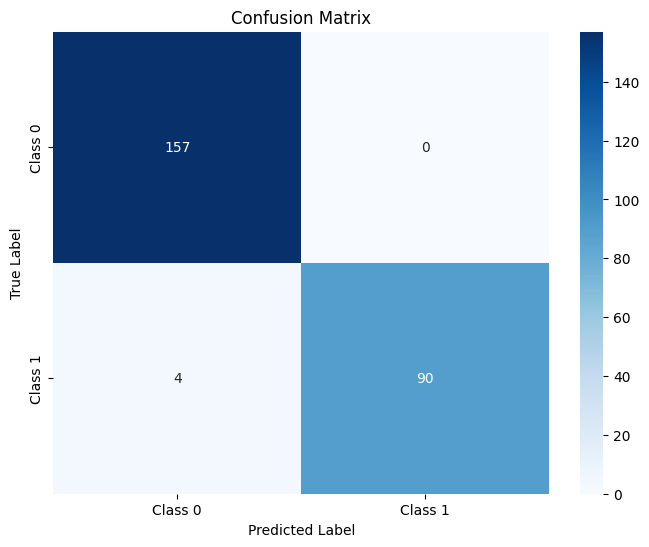


Accuracy: 0.98


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test contains the true labels and y_pred_test_label contains the predicted labels
conf_matrix = confusion_matrix(y_test, y_pred_test_label)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred_test_label)
print(f"\nAccuracy: {accuracy:.2f}")

In [27]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

y_prob = model.predict(x_test_s)

fpr, tpr, threshold = roc_curve(y_test, y_prob)

# Compute ROC curve and ROC area
roc_auc = auc(fpr, tpr)
print(f"ROC - Area :{roc_auc}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step
ROC - Area :0.9976284049329178


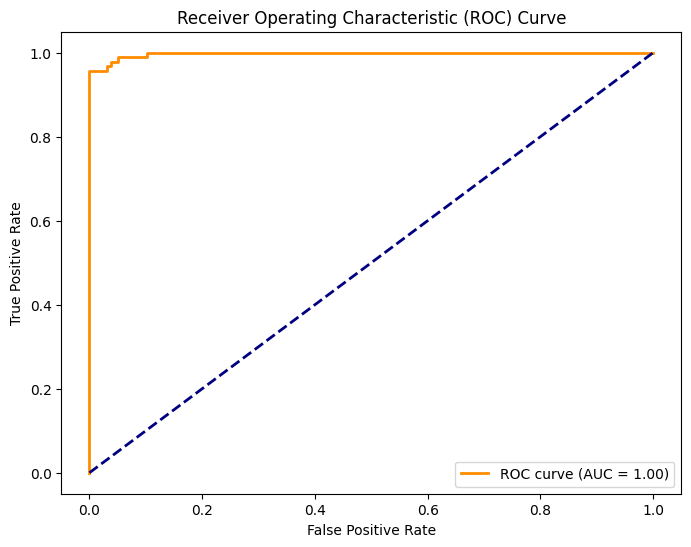

In [28]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [29]:
y_prob = model.predict(x_test_s)

precision, recall, threshold = precision_recall_curve(y_test, y_prob)

# Compute ROC curve and ROC area
pr_auc = auc(recall,precision)
print(f"PR - Area :{pr_auc}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
PR - Area :0.9963869865465318


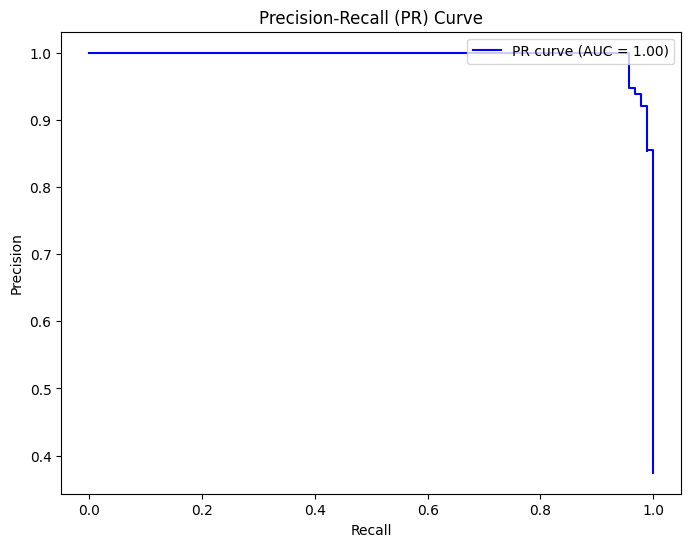

In [30]:
# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', where='post', label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (PR) Curve')
plt.legend(loc='upper right')
plt.show()

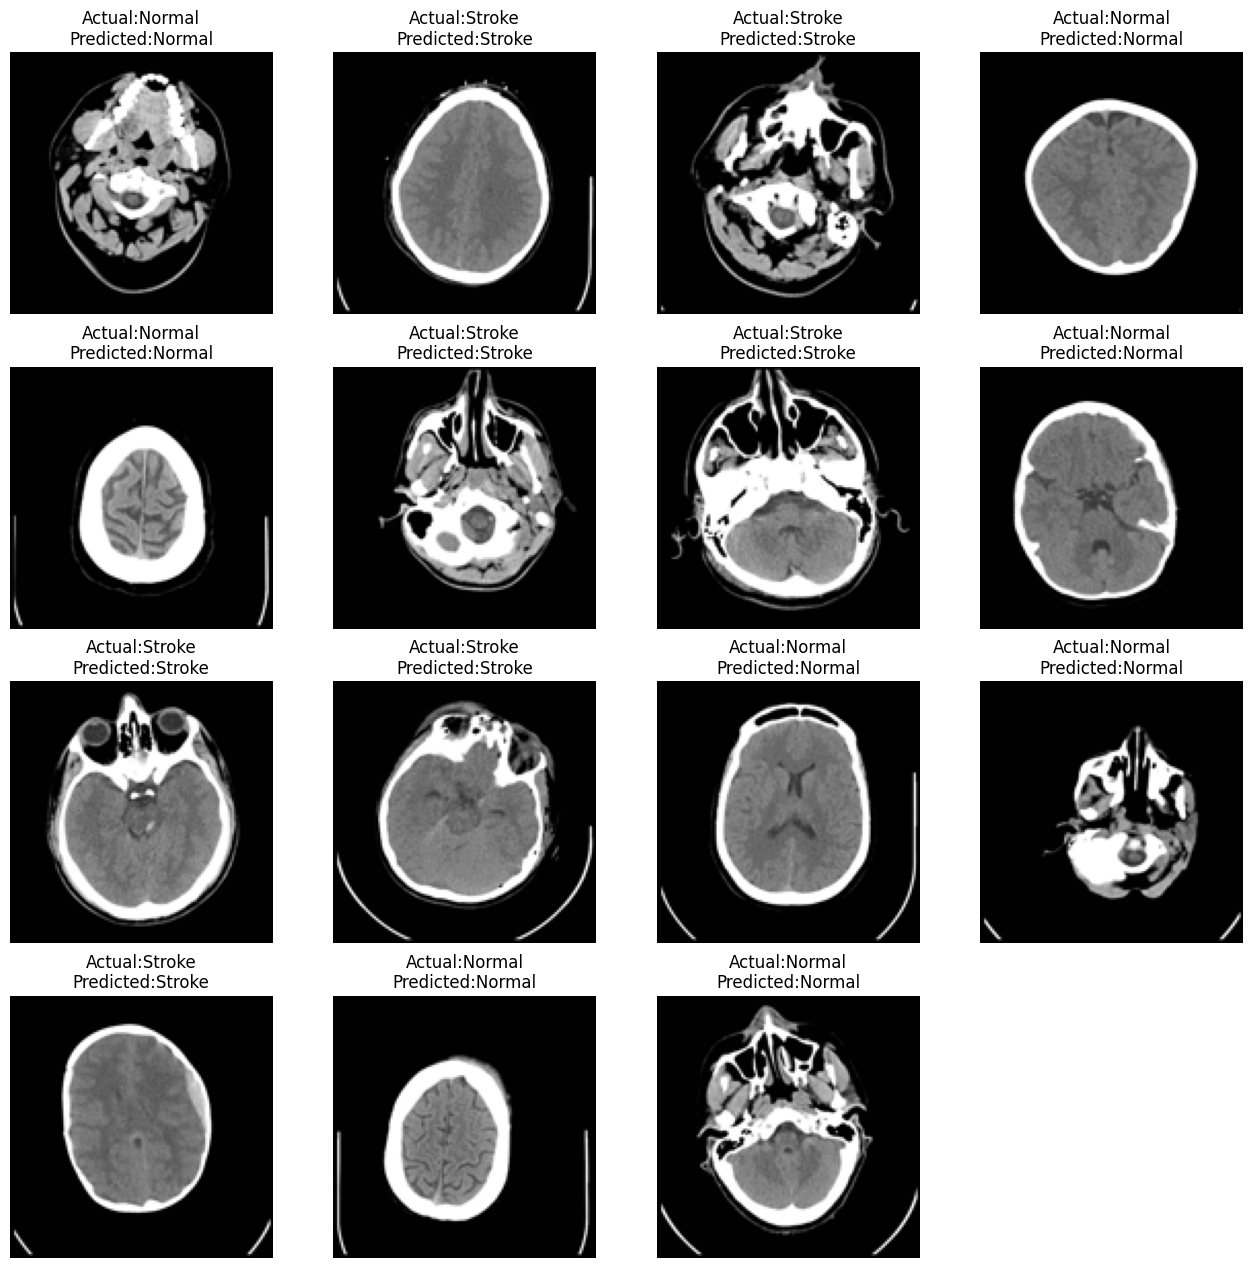

In [31]:
class_labels = ["Normal","Stroke"]
plt.figure(figsize=(16,32))
for i in range(15):
    plt.subplot(8,4,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Actual:{class_labels[y_test[i]]}\nPredicted:{class_labels[y_pred_test_label[i]]}")
    plt.axis("off")

In [49]:
train_datagen = ImageDataGenerator(
    rescale=1./255,    # Normalize pixel values
    rotation_range=20,  # Random rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale for testing


In [50]:
train_dir = "C:\\Brain Stroke image dataset\\Brain_Data_Organised"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 2001 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 2501 images belonging to 2 classes.


In [51]:
from keras.applications import VGG16

# Load pre-trained VGG16 model without top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

# Define new model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [52]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.5554 - loss: 0.7691 - val_accuracy: 0.6400 - val_loss: 0.6317
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.5660 - loss: 0.7079 - val_accuracy: 0.6740 - val_loss: 0.6168
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.6113 - loss: 0.6708 - val_accuracy: 0.6800 - val_loss: 0.6124
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.6232 - loss: 0.6674 - val_accuracy: 0.6380 - val_loss: 0.6172
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.6355 - loss: 0.6441 - val_accuracy: 0.6560 - val_loss: 0.6058
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.6400 - loss: 0.6309 - val_accuracy: 0.6580 - val_loss: 0.6226
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.6466 - loss: 0.6364 - val_accuracy: 0.6760 - val_loss: 0.6148
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.6495 - loss: 0.6311 - val_accuracy: 0.6300 - v

In [53]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.2f}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8351 - loss: 0.4922
Test Accuracy: 0.73


79/79 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step


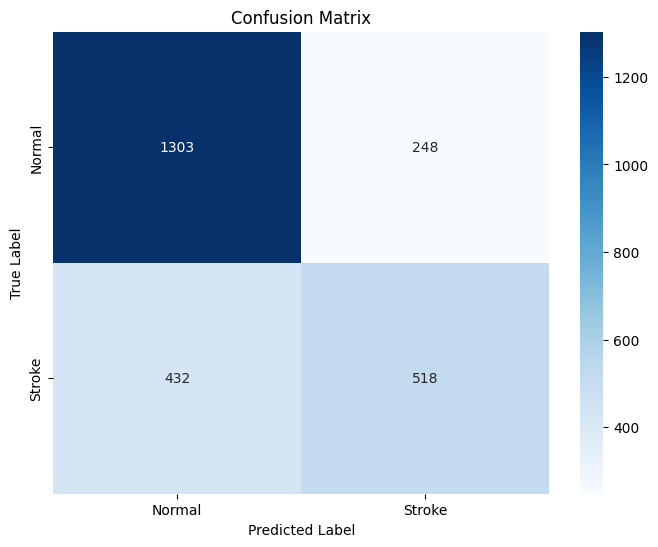

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79      1551
           1       0.68      0.55      0.60       950

    accuracy                           0.73      2501
   macro avg       0.71      0.69      0.70      2501
weighted avg       0.72      0.73      0.72      2501



In [ ]:
# Predict the test set
y_pred_probs = model.predict(test_generator)
y_pred = [1 if i > 0.5 else 0 for i in y_pred_probs]

# Get true labels
y_true = test_generator.classes

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Stroke'], yticklabels=['Normal', 'Stroke'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred))


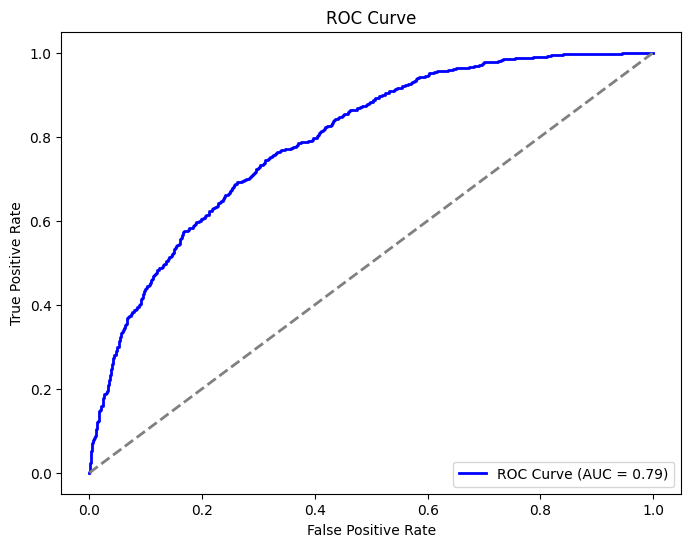

In [55]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [56]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load Pretrained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze initial layers (Only train top layers)
for layer in base_model.layers[:-10]:  
    layer.trainable = False

# Create model
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(1, activation='sigmoid')(x)  # Binary classification

resnet_model = Model(inputs=base_model.input, outputs=x)

# Compile ResNet model
resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 49,278,337 (187.98 MB)

 Trainable params: 30,156,289 (115.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [57]:
history_resnet = resnet_model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.5566 - loss: 1.2639 - val_accuracy: 0.6200 - val_loss: 0.6587
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.6220 - loss: 0.6606 - val_accuracy: 0.6200 - val_loss: 0.6583
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.6414 - loss: 0.6484 - val_accuracy: 0.6240 - val_loss: 0.6488
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.6355 - loss: 0.6585 - val_accuracy: 0.6340 - val_loss: 0.6569
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.6437 - loss: 0.6545 - val_accuracy: 0.6360 - val_loss: 0.6507
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.6443 - loss: 0.6410 - val_accuracy: 0.6380 - val_loss: 0.6477
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.6436 - loss: 0.6420 - val_accuracy: 0.6280 - val_loss: 0.6402
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.6453 - loss: 0.6421 - val_accuracy: 0.6480 - v

In [58]:
loss, acc = resnet_model.evaluate(validation_generator)
print(f"ResNet50 Model Accuracy: {acc*100:.2f}%")


16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6785 - loss: 0.6329
ResNet50 Model Accuracy: 65.00%


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # ✅ Resize images to match EfficientNetB3 input size
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # ✅ Ensure validation images are also resized
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 2001 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [13]:
# Load EfficientNetB3 without the top classification layer
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze Base Model (so only new layers will be trained initially)
base_model.trainable = False


In [14]:
# Add Custom Classification Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Convert feature maps into a single vector
x = Dense(512, activation='relu')(x)  # Fully connected layer
x = Dropout(0.4)(x)  # Dropout to reduce overfitting
x = Dense(1, activation='sigmoid')(x)  # Binary classification (Ensure it's connected)

# Define Model
model = Model(inputs=base_model.input, outputs=x)  # Fix: Ensure x is properly built

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display Summary
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,570,992 (44.14 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [15]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)


Epoch 1/20


c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.6002 - loss: 0.6828 - val_accuracy: 0.6200 - val_loss: 0.6635
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.6287 - loss: 0.6645 - val_accuracy: 0.6200 - val_loss: 0.6662
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6155 - loss: 0.6710 - val_accuracy: 0.6200 - val_loss: 0.6642
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5972 - loss: 0.6738 - val_accuracy: 0.6200 - val_loss: 0.6694
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6156 - loss: 0.6729 - val_accuracy: 0.6200 - val_loss: 0.6645
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6234 - loss: 0.6660 - val_accuracy: 0.6200 - val_loss: 0.6638
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6083 - loss: 0.6744 - val_accuracy: 0.6200 - val_loss: 0.6652
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6208 - loss: 0.6689 - val_accuracy: 0.6200 - val_loss: 0.

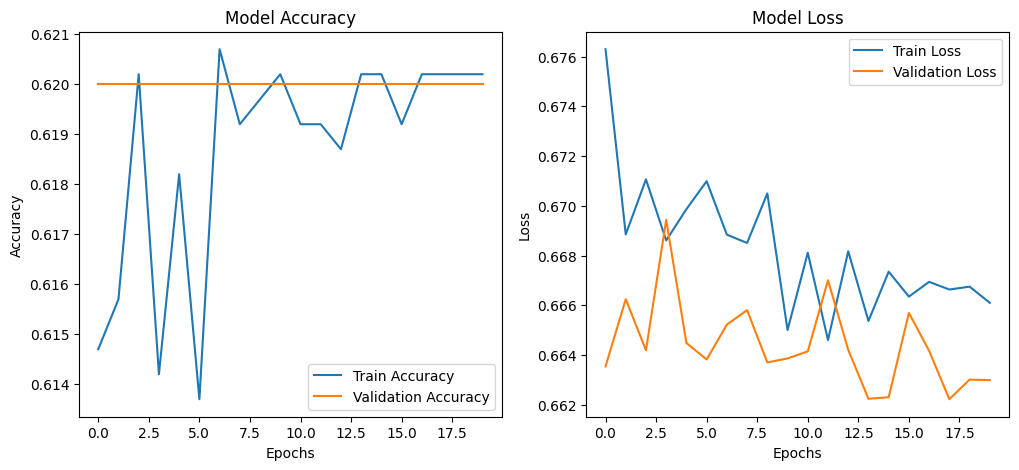

In [16]:
# Plot Accuracy & Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()


In [20]:
# Evaluate EfficientNetB3 model on validation set
loss, acc = model.evaluate(train_generator)

# Print Accuracy
print(f"EfficientNetB3 Model Accuracy: {acc * 100:.2f}%")


63/63 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6096 - loss: 0.6695
EfficientNetB3 Model Accuracy: 62.02%
